In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels import robust

%matplotlib inline

## Data Loading

Pada chapter ini digunakan beberapa dataset untuk mendemonstrasikan konsep Exploratory Data Analysis (EDA), termasuk data populasi dan murder rate tiap negara bagian Amerika Serikat serta data return saham S&P 500.

Dataset dimuat terlebih dahulu agar seluruh contoh kode pada chapter dapat dijalankan secara berurutan.

In [2]:
import os

DATA_DIR = '../data'

# State data
state = pd.read_csv(
    os.path.join(DATA_DIR, 'state.csv')
)

# S&P 500 data
sp500_px = pd.read_csv(
    os.path.join(DATA_DIR, 'sp500_data.csv.gz'),
    index_col=0,
    parse_dates=True
)

sp500_sym = pd.read_csv(
    os.path.join(DATA_DIR, 'sp500_sectors.csv')
)

# King County tax data
kc_tax = pd.read_csv(
    os.path.join(DATA_DIR, 'kc_tax.csv.gz')
)

# Lending Club loans
lc_loans = pd.read_csv(
    os.path.join(DATA_DIR, 'lc_loans.csv')
)

# Airline statistics
airline_stats = pd.read_csv(
    os.path.join(DATA_DIR, 'airline_stats.csv')
)

# DFW airline data
dfw_airline = pd.read_csv(
    os.path.join(DATA_DIR, 'dfw_airline.csv')
)

print('state:', state.shape)
print('sp500_px:', sp500_px.shape)
print('sp500_sym:', sp500_sym.shape)
print('kc_tax:', kc_tax.shape)
print('lc_loans:', lc_loans.shape)
print('airline_stats:', airline_stats.shape)
print('dfw_airline:', dfw_airline.shape)

state: (50, 4)
sp500_px: (5647, 517)
sp500_sym: (517, 4)
kc_tax: (498249, 3)
lc_loans: (450961, 2)
airline_stats: (33468, 4)
dfw_airline: (1, 5)


# Chapter 1 — Exploratory Data Analysis

**Book:** Practical Statistics for Data Scientists, 2nd Edition  
**Authors:** Peter Bruce, Andrew Bruce, Peter Gedeck  
**Implementation:** Python  
**Chapter:** 1 — Exploratory Data Analysis

---

## 1. Introduction

Exploratory Data Analysis (EDA) merupakan pendekatan untuk memahami data
sebelum melakukan analisis statistik atau pemodelan lebih lanjut.

EDA digunakan untuk melihat karakteristik utama data melalui ringkasan
statistik dan visualisasi. Beberapa hal yang dapat dipelajari melalui EDA
antara lain lokasi atau central tendency, variability, distribusi data,
outlier, serta hubungan antarvariabel.

Chapter ini membahas beberapa konsep utama:

1. Elements of Structured Data
2. Rectangular Data
3. Estimates of Location
4. Estimates of Variability
5. Exploring the Data Distribution
6. Exploring Binary and Categorical Data
7. Correlation
8. Exploring Two or More Variables

### Objective

Tujuan notebook ini adalah mempelajari ulang contoh Python pada Chapter 1 serta
menjelaskan konsep statistik yang digunakan pada setiap bagian.

Setiap bagian akan terdiri dari:

- penjelasan teori;
- implementasi Python;
- output atau visualisasi;
- interpretasi hasil.

## 2. Elements of Structured Data

Data yang digunakan dalam data science dapat memiliki berbagai bentuk dan
struktur. Salah satu struktur yang paling dasar adalah **rectangular
data**, yaitu data yang disusun dalam baris dan kolom.

Beberapa istilah penting dalam structured data adalah:

- **Record:** satu baris yang merepresentasikan satu observasi.
- **Feature:** variabel yang digunakan untuk mendeskripsikan setiap record.
- **Outcome:** variabel yang menjadi hasil atau target yang ingin dijelaskan
  atau diprediksi.
- **Numeric data:** data yang berupa nilai numerik.
- **Categorical data:** data yang menunjukkan kategori atau kelompok.
- **Binary data:** categorical data yang hanya memiliki dua kemungkinan nilai.
- **Ordinal data:** categorical data yang memiliki urutan atau ranking.

Dalam praktik data science, istilah-istilah tersebut dapat digunakan secara
berbeda tergantung bidangnya. Namun, pemahaman terhadap struktur data sangat
penting sebelum melakukan analisis statistik.

In [3]:
example_data = pd.DataFrame({
    "Age": [20, 21, 22, 23],
    "StudyHours": [2.5, 4.0, 3.0, 5.0],
    "Passed": [True, True, False, True]
})

example_data

,Age,StudyHours,Passed
0,20,2.5,True
1,21,4.0,True
2,22,3.0,False
3,23,5.0,True


### Interpretation

Data di atas merupakan contoh sederhana dari rectangular data.

Setiap baris merupakan satu **record** atau observasi. Kolom `Age` dan
`StudyHours` merupakan numeric variables, sedangkan `Passed` merupakan
binary variable karena hanya mempunyai dua kemungkinan nilai, yaitu `True`
dan `False`.

Contoh ini menunjukkan bahwa satu dataset dapat memiliki beberapa tipe
variabel yang berbeda dan setiap variabel mempunyai peran yang berbeda dalam
analisis.

## 3. Rectangular Data

Rectangular data merupakan data yang disusun dalam bentuk tabel dengan baris
dan kolom.

Dalam struktur ini:

- setiap **row** merepresentasikan satu record atau observation;
- setiap **column** merepresentasikan sebuah variable atau feature;
- sebuah variable dapat digunakan sebagai predictor atau outcome, tergantung
  tujuan analisis.

Data frame merupakan salah satu bentuk rectangular data yang umum digunakan
dalam Python melalui library pandas.

Struktur rectangular sangat penting dalam data science karena banyak metode
statistik dan machine learning bekerja dengan data yang disusun dalam bentuk
baris dan kolom.

In [4]:
state = pd.read_csv("../data/state.csv")

state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [5]:
state.shape

(50, 4)

In [6]:
state.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     str    
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.7 KB


In [7]:
state.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


### Interpretation

Dataset `state` merupakan contoh rectangular data yang digunakan dalam
Chapter 1.

Dataset terdiri dari 50 records dan 4 variables. Setiap record mewakili
sebuah state, sedangkan variables digunakan untuk menggambarkan karakteristik
state tersebut.

`Population` merupakan variabel numerik yang menunjukkan jumlah penduduk,
sedangkan `Murder.Rate` merupakan variabel numerik yang menunjukkan murder
rate.

Dengan menggunakan pandas, kita dapat melihat struktur, ukuran, dan ringkasan
statistik dataset sebelum melakukan analisis yang lebih mendalam.

## 4. Estimates of Location

Setelah memahami struktur data, langkah berikutnya adalah memahami lokasi
atau central tendency dari suatu variabel.

Central tendency memberikan gambaran mengenai nilai yang dapat dianggap
mewakili pusat data.

Beberapa ukuran yang dibahas dalam chapter ini adalah:

- Mean
- Weighted mean
- Median
- Weighted median
- Trimmed mean
- Percentile

Mean merupakan jumlah seluruh nilai dibagi dengan jumlah observasi.

Median merupakan nilai tengah dari data yang telah diurutkan.

Mean dapat terpengaruh oleh nilai ekstrem atau outlier, sedangkan median
lebih robust terhadap outlier. Oleh karena itu, pemilihan ukuran central
tendency harus mempertimbangkan karakteristik distribusi data.

In [8]:
state["Population"].mean()

np.float64(6162876.3)

In [9]:
np.mean(state["Population"])

np.float64(6162876.3)

In [10]:
state["Population"].median()

np.float64(4436369.5)

### Median

Median membagi data yang telah diurutkan menjadi dua bagian.

Sebanyak sekitar setengah observasi berada di bawah median dan setengah
lainnya berada di atas median.

Berbeda dengan mean, median relatif tidak sensitif terhadap nilai ekstrem.
Karena itu, median merupakan ukuran lokasi yang lebih robust ketika distribusi
data memiliki outlier.

In [11]:
population = state["Population"]

print("Mean   :", population.mean())
print("Median :", population.median())
print("Maximum:", population.max())

Mean   : 6162876.3
Median : 4436369.5
Maximum: 37253956


### Interpretation

Perbedaan antara mean dan median menunjukkan bahwa distribusi population tidak
sepenuhnya simetris.

Beberapa state memiliki population yang jauh lebih besar daripada sebagian
besar state lainnya. Nilai ekstrem seperti ini memberikan pengaruh lebih besar
terhadap mean dibandingkan median.

Hal ini merupakan salah satu alasan mengapa median sering digunakan sebagai
ukuran lokasi yang robust.

In [12]:
from scipy.stats import trim_mean

trimmed_mean = trim_mean(state["Population"], proportiontocut=0.1)

trimmed_mean

np.float64(4783697.125)

### Trimmed Mean

Trimmed mean merupakan alternatif terhadap mean ketika terdapat kemungkinan
bahwa nilai ekstrem memberikan pengaruh yang terlalu besar.

Dalam contoh ini, sebagian nilai paling rendah dan paling tinggi dikeluarkan
sebelum mean dihitung.

Karena nilai ekstrem tidak lagi memberikan pengaruh penuh, trimmed mean
biasanya berada di antara karakteristik yang diberikan oleh mean biasa dan
ukuran lokasi yang lebih robust seperti median.

In [13]:
weighted_mean = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_mean

np.float64(4.445833981123393)

### Weighted Mean

Weighted mean memberikan bobot yang berbeda kepada setiap observasi.

Pada contoh ini, `Population` digunakan sebagai weight untuk `Murder.Rate`.

Artinya, state dengan population yang lebih besar memberikan kontribusi yang
lebih besar terhadap weighted mean dibandingkan state dengan population yang
lebih kecil.

Konsep ini berbeda dari mean biasa, yang memberikan bobot yang sama kepada
setiap observasi.

In [14]:
mean_population = state["Population"].mean()
median_population = state["Population"].median()
trimmed_mean_population = trim_mean(
    state["Population"],
    proportiontocut=0.1
)

pd.DataFrame({
    "Measure": [
        "Mean",
        "Median",
        "Trimmed Mean"
    ],
    "Population": [
        mean_population,
        median_population,
        trimmed_mean_population
    ]
})

,Measure,Population
0,Mean,6162876.300
1,Median,4436369.500
2,Trimmed Mean,4783697.125


### Comparison

Perbandingan mean, median, dan trimmed mean menunjukkan bahwa satu dataset
dapat memiliki beberapa ukuran central tendency yang berbeda.

Mean menggunakan seluruh nilai dan sangat dipengaruhi oleh nilai ekstrem.
Median lebih robust terhadap nilai ekstrem, sedangkan trimmed mean mengurangi
pengaruh nilai ekstrem dengan mengeluarkan sebagian observasi pada kedua
ujung distribusi.

Oleh karena itu, ketiga ukuran tersebut sebaiknya dipahami bersama, bukan
digunakan secara terpisah tanpa melihat distribusi datanya.

## 5. Estimates of Variability

Location hanya menjelaskan posisi pusat data. Kita juga perlu mengetahui
seberapa tersebar nilai-nilai data tersebut.

Variability, yang juga disebut dispersion, mengukur apakah nilai data
cenderung terkumpul di sekitar nilai pusat atau tersebar jauh.

Beberapa ukuran variability yang dibahas dalam chapter ini adalah:

- **Variance:** jumlah squared deviations dari mean dibagi dengan `n - 1`.
- **Standard deviation:** akar kuadrat dari variance.
- **Mean absolute deviation:** rata-rata nilai absolut dari deviations terhadap
  mean.
- **Median absolute deviation (MAD):** median dari nilai absolut deviations
  terhadap median.
- **Range:** selisih antara nilai terbesar dan nilai terkecil.
- **Percentile:** nilai yang membagi data berdasarkan persentase observasi.
- **Interquartile range (IQR):** selisih percentile ke-75 dan percentile ke-25.

Variance dan standard deviation merupakan ukuran variability yang paling umum,
tetapi keduanya sensitif terhadap outlier. Ukuran seperti MAD dan IQR lebih
robust terhadap nilai ekstrem.

In [15]:
state["Population"].std()

np.float64(6848235.347401142)

In [16]:
state["Population"].quantile(0.75) - state["Population"].quantile(0.25)

np.float64(4847308.0)

In [17]:
robust.mad(state["Population"])

np.float64(3849876.1459979336)

### Interpretation

Standard deviation dan MAD memberikan informasi mengenai penyebaran data,
tetapi memiliki sensitivitas yang berbeda terhadap outlier.

Standard deviation sensitif terhadap nilai ekstrem karena deviation
dikuadratkan dalam perhitungan variance.

MAD lebih robust karena menggunakan median dari absolute deviations.

Pada dataset population, standard deviation jauh lebih besar daripada MAD.
Hal ini konsisten dengan adanya beberapa state dengan population yang sangat
besar dibandingkan sebagian besar state lainnya.

### Percentiles

Percentile digunakan untuk melihat posisi relatif suatu nilai dalam distribusi.

Pada chapter ini, percentile juga digunakan sebagai cara untuk melihat
keseluruhan distribusi, bukan hanya sebagai ukuran variability.

Untuk murder rate, buku menggunakan percentile:

- 5%
- 25%
- 50%
- 75%
- 95%

In [18]:
state["Murder.Rate"].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

### Interpretation

Median murder rate adalah sekitar 4 murders per 100,000 people.

Namun, percentile ke-5 berada sekitar 1.6 sedangkan percentile ke-95 sekitar
6.51. Perbedaan tersebut menunjukkan adanya variability yang cukup besar pada
murder rate antar-state.

Percentiles membantu kita melihat bagian tengah sekaligus bagian ekor
distribusi.

## 6. Exploring the Data Distribution

Ukuran seperti mean, median, dan standard deviation merangkum data menjadi
beberapa angka. Namun, ringkasan tersebut belum sepenuhnya menunjukkan bentuk
distribusi data.

Karena itu, EDA juga menggunakan visualisasi untuk melihat distribusi secara
keseluruhan.

Teknik yang dibahas dalam chapter ini meliputi:

- Percentiles
- Boxplots
- Frequency tables
- Histograms
- Density plots

Boxplot memberikan ringkasan distribusi berdasarkan percentile. Histogram
mengelompokkan data ke dalam bins dan menghitung frekuensi. Density plot
memberikan representasi distribusi yang lebih halus.

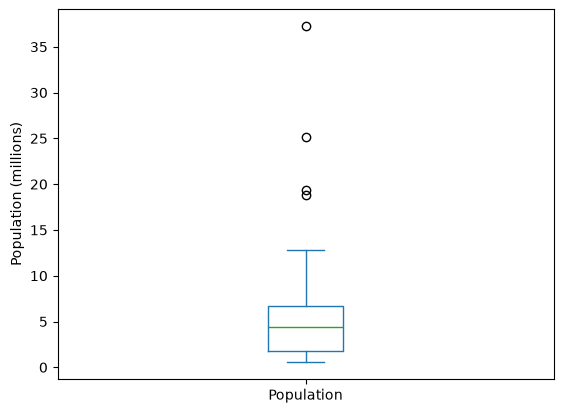

In [19]:
ax = (state["Population"] / 1_000_000).plot.box()

ax.set_ylabel("Population (millions)")
plt.show()

### Interpretation

Boxplot menunjukkan median, quartiles, dan potential outliers.

Bagian bawah box menunjukkan percentile ke-25, sedangkan bagian atas
menunjukkan percentile ke-75. Garis di dalam box menunjukkan median.

Whiskers menunjukkan rentang utama data. Observasi yang berada di luar
whiskers dapat ditampilkan sebagai individual points dan sering dianggap
sebagai outliers.

Pada population dataset, terlihat beberapa state dengan population yang jauh
lebih besar dibandingkan sebagian besar state lainnya.

### Frequency Table

Frequency table membagi rentang nilai menjadi beberapa interval atau bins,
kemudian menghitung berapa banyak observasi yang berada pada setiap interval.

Berbeda dengan percentile yang menghasilkan bins dengan jumlah observasi yang
relatif sama, frequency table pada contoh ini menggunakan bins dengan ukuran
interval yang sama.

In [20]:
binnedPopulation = pd.cut(state["Population"], 10)

binnedPopulation.value_counts().sort_index()

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64

In [21]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts()

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64

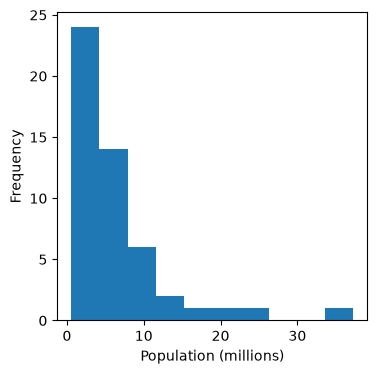

In [22]:
ax = (state["Population"] / 1_000_000).plot.hist(
    figsize=(4, 4)
)

ax.set_xlabel("Population (millions)")
plt.show()

### Interpretation

Histogram merupakan visualisasi dari frequency table.

Sumbu x menunjukkan interval atau bins, sedangkan sumbu y menunjukkan jumlah
observasi dalam setiap bin.

Pada population dataset, sebagian besar state berada pada population yang
relatif rendah hingga menengah, sedangkan beberapa state mempunyai population
yang sangat tinggi.

Bin kosong juga memiliki informasi karena menunjukkan tidak adanya observasi
pada interval tersebut.

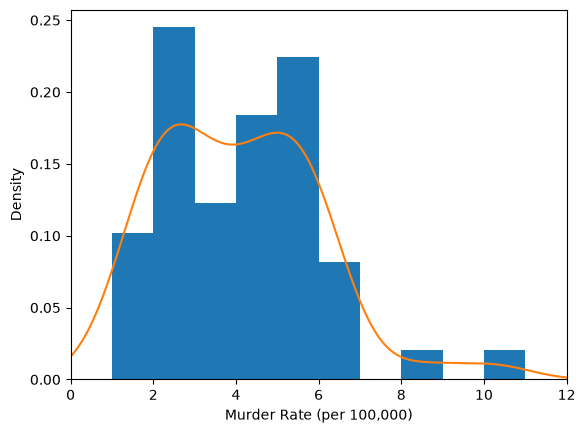

In [23]:
ax = state["Murder.Rate"].plot.hist(
    density=True,
    xlim=[0, 12],
    bins=range(1, 12)
)

state["Murder.Rate"].plot.density(ax=ax)

ax.set_xlabel("Murder Rate (per 100,000)")
plt.show()

### Interpretation

Density plot dapat dipandang sebagai versi histogram yang diperhalus.

Berbeda dengan histogram biasa yang menggunakan count pada sumbu y, density
plot menggunakan skala density. Total area di bawah density curve adalah 1.

Dengan demikian, area di bawah kurva pada suatu interval dapat
diinterpretasikan sebagai proporsi distribusi yang berada pada interval
tersebut.

## 7. Exploring Binary and Categorical Data

Categorical data merepresentasikan kelompok atau kategori, bukan pengukuran
numerik kontinu.

Untuk categorical data, proporsi atau persentase sering kali sudah cukup
untuk memberikan gambaran mengenai data.

Konsep utama pada bagian ini adalah:

- **Mode:** kategori atau nilai yang paling sering muncul.
- **Expected value:** nilai rata-rata yang diperoleh berdasarkan probabilitas
  setiap kategori.
- **Probability:** peluang suatu kategori terjadi.
- **Bar chart:** visualisasi frekuensi atau proporsi setiap kategori.

Bar chart harus dibedakan dari histogram. Bar chart digunakan untuk kategori,
sedangkan histogram digunakan untuk numeric data yang dibagi ke dalam bins.

In [24]:
binary_data = pd.Series([
    "Yes",
    "No",
    "Yes",
    "Yes",
    "No",
    "Yes",
    "No",
    "Yes"
])

binary_data.value_counts()

Yes    5
No     3
Name: count, dtype: int64

In [25]:
binary_data.value_counts(normalize=True)

Yes    0.625
No     0.375
Name: proportion, dtype: float64

### Interpretation

`value_counts()` menghitung jumlah kemunculan setiap kategori.

Dengan menggunakan `normalize=True`, hasilnya berubah dari count menjadi
proportion.

Untuk binary variable, proportion dapat langsung digunakan untuk melihat
berapa bagian observasi berada pada masing-masing kategori.

In [26]:
binary_data.mode()

0    Yes
dtype: str

### Mode

Mode merupakan kategori atau nilai yang paling sering muncul dalam dataset.

Untuk categorical data, mode dapat menjadi ringkasan sederhana mengenai
kategori yang paling umum.

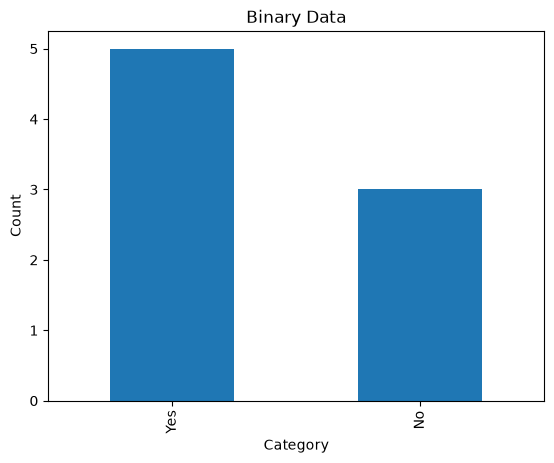

In [27]:
ax = binary_data.value_counts().plot.bar()

ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.set_title("Binary Data")
plt.show()

### Interpretation

Bar chart memperlihatkan frekuensi setiap kategori.

Berbeda dengan histogram, kategori pada bar chart tidak merepresentasikan
interval numeric yang berurutan. Karena itu, bar pada bar chart dipisahkan,
sedangkan histogram biasanya menggunakan bar yang berdempetan.

In [28]:
from statsmodels import robust

In [29]:
robust.scale.mad(state["Population"])

np.float64(3849876.1459979336)

## 8. Correlation

Correlation digunakan untuk mengeksplorasi hubungan antara dua numeric
variables.

Dua variabel dikatakan memiliki positive correlation ketika nilai tinggi dari
satu variabel cenderung berpasangan dengan nilai tinggi dari variabel lainnya.

Sebaliknya, negative correlation terjadi ketika nilai tinggi dari satu variabel
cenderung berpasangan dengan nilai rendah dari variabel lainnya.

Konsep utama:

- **Correlation coefficient:** ukuran hubungan antara dua numeric variables.
- **Correlation matrix:** tabel yang menunjukkan correlation antar banyak
  variabel.
- **Scatterplot:** visualisasi hubungan antara dua numeric variables.

Pearson correlation coefficient memiliki rentang -1 sampai +1:

- `+1` menunjukkan perfect positive correlation.
- `-1` menunjukkan perfect negative correlation.
- `0` menunjukkan tidak adanya linear correlation.

In [30]:
state[["Population", "Murder.Rate"]].corr()

,Population,Murder.Rate
Population,1.000000,0.182069
Murder.Rate,0.182069,1.000000


### Interpretation

Correlation coefficient merupakan ukuran standardized sehingga nilainya
selalu berada antara -1 dan +1.

Nilai positif menunjukkan kecenderungan kedua variabel meningkat bersama,
sedangkan nilai negatif menunjukkan kecenderungan satu variabel meningkat
ketika variabel lainnya menurun.

Namun, correlation coefficient terutama menggambarkan hubungan linear.
Hubungan yang nonlinear dapat menyebabkan correlation coefficient tidak
memberikan gambaran hubungan yang lengkap.

In [31]:
telecom = sp500_px[['T', 'CTL', 'FTR', 'VZ', 'LVLT']]

telecom.head()

,T,CTL,FTR,VZ,LVLT
1993-01-29,-0.216268,-0.463919,0.000000,-0.064076,0.0
1993-02-01,0.096119,0.173973,0.014497,0.149513,0.0
1993-02-02,0.072089,0.086986,0.028998,0.085437,0.0
1993-02-03,0.000000,0.000000,-0.028997,0.106797,0.0
1993-02-04,-0.048059,0.289952,0.028998,-0.106792,0.0


In [32]:
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.405853,0.283279,0.617035,0.061545
CTL,0.405853,1.000000,0.377644,0.385752,0.054534
FTR,0.283279,0.377644,1.000000,0.289295,0.067313
VZ,0.617035,0.385752,0.289295,1.000000,0.045919
LVLT,0.061545,0.054534,0.067313,0.045919,1.000000


### Correlation Heatmap

Correlation matrix dapat divisualisasikan menggunakan heatmap.

Heatmap memberikan representasi visual mengenai kekuatan dan arah correlation
antara beberapa variables.

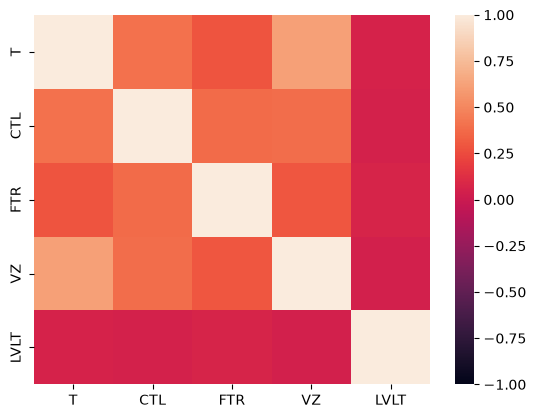

In [33]:
sns.heatmap(
    telecom.corr(),
    vmin=-1,
    vmax=1
)

plt.show()

### Scatterplot

Scatterplot digunakan untuk melihat hubungan antara dua variabel numerik.

Setiap titik merepresentasikan satu observasi. Posisi titik ditentukan oleh nilai pada sumbu x dan sumbu y.

Scatterplot membantu melihat:
- arah hubungan,
- kekuatan hubungan,
- pola hubungan,
- serta kemungkinan outlier.

Pada contoh berikut digunakan return saham AT&T (T) dan Verizon (VZ).

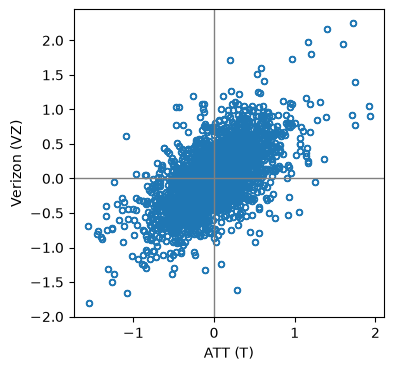

In [34]:
ax = telecom.plot.scatter(
    x='T',
    y='VZ',
    figsize=(4, 4),
    marker='$\u25EF$'
)

ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

### Interpretasi

Scatterplot menunjukkan hubungan positif antara return saham T dan VZ. Ketika return salah satu saham cenderung positif, return saham lainnya juga cenderung positif, dan demikian pula ketika keduanya negatif.

Sebagian besar observasi terkonsentrasi di sekitar pusat grafik. Pola ini menunjukkan bahwa kedua saham memiliki kecenderungan bergerak dalam arah yang sama.

In [35]:
kc_tax0 = kc_tax.loc[
    (kc_tax.TaxAssessedValue < 750000) &
    (kc_tax.SqFtTotLiving > 100) &
    (kc_tax.SqFtTotLiving < 3500),
    :
]

kc_tax0.shape

(432693, 3)

### Hexbin Plot

Ketika jumlah observasi sangat besar, scatterplot dapat menghasilkan kumpulan titik yang terlalu padat sehingga pola distribusi sulit dilihat.

Hexbin plot membagi bidang menjadi beberapa area berbentuk hexagon dan menghitung jumlah observasi pada setiap area. Dengan demikian, konsentrasi data dapat dilihat dengan lebih jelas.

Text(0, 0.5, 'Tax-Assessed Value')

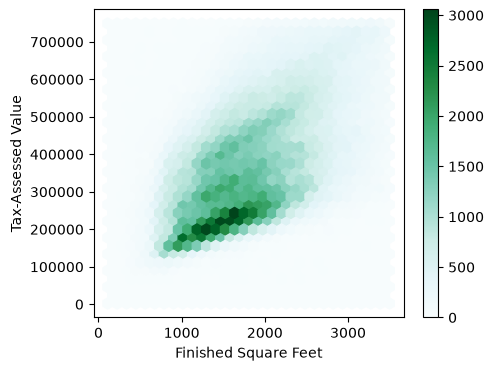

In [36]:
ax = kc_tax0.plot.hexbin(
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    gridsize=30,
    sharex=False,
    figsize=(5, 4)
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

### Contour Plot

Contour plot menggambarkan kepadatan observasi menggunakan garis kontur. Area dengan kepadatan data yang lebih tinggi ditunjukkan oleh kontur yang lebih terkonsentrasi.

Visualisasi ini memberikan alternatif terhadap hexbin plot untuk melihat bentuk distribusi dua variabel numerik.

Text(0, 0.5, 'Tax-Assessed Value')

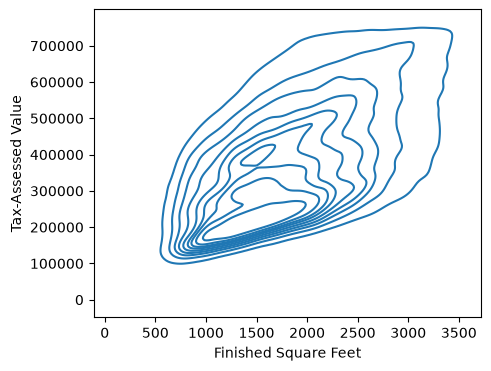

In [37]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.kdeplot(
    x=kc_tax0.SqFtTotLiving,
    y=kc_tax0.TaxAssessedValue,
    ax=ax
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

### Two Categorical Variables

Contingency table digunakan untuk merangkum hubungan antara dua variabel kategorikal.

Pada contoh ini:
- `grade` menunjukkan grade pinjaman.
- `status` menunjukkan status atau outcome pinjaman.

Tabel menghitung jumlah pinjaman pada setiap kombinasi kategori.

In [38]:
crosstab = lc_loans.pivot_table(
    index='grade',
    columns='status',
    aggfunc=lambda x: len(x),
    margins=True
)

crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [44]:
df = crosstab.loc['A':'G', :].copy()

cols = df.loc[:, 'Charged Off':'Late'].columns

df[cols] = (
    df[cols]
    .div(df['All'], axis=0)
)

df['All'] = df['All'] / sum(df['All'])

perc_crosstab = df

perc_crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.021548,0.690454,0.281528,0.006470,0.160746
B,0.040054,0.709013,0.235401,0.015532,0.293529
C,0.049828,0.735702,0.191495,0.022974,0.268039
D,0.067410,0.717328,0.184189,0.031073,0.164708
E,0.081657,0.707936,0.170929,0.039478,0.077177
F,0.118258,0.654371,0.180409,0.046962,0.028614
G,0.126196,0.614008,0.198396,0.061401,0.007187


### Categorical Variable vs Numeric Variable

Boxplot dapat digunakan untuk membandingkan distribusi variabel numerik pada beberapa kelompok kategorikal.

Pada contoh ini, persentase penerbangan yang terlambat dibandingkan berdasarkan maskapai.

Text(0.5, 0.98, '')

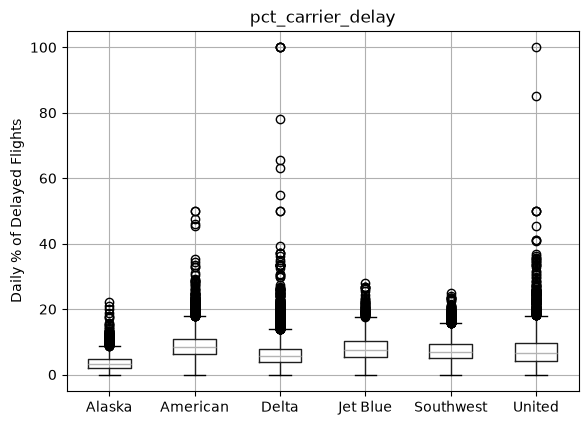

In [40]:
ax = airline_stats.boxplot(
    by='airline',
    column='pct_carrier_delay'
)

ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.suptitle('')

### Violin Plot

Violin plot menampilkan bentuk distribusi data melalui estimasi density.

Dibandingkan boxplot, violin plot memberikan informasi lebih banyak mengenai bentuk distribusi. Namun, boxplot lebih sederhana untuk membaca median, kuartil, dan outlier.

Text(0, 0.5, 'Daily % of Delayed Flights')

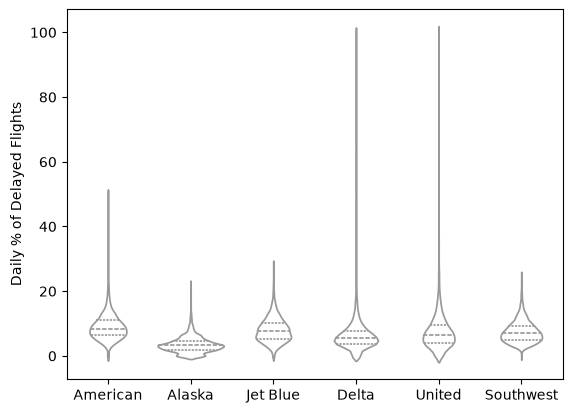

In [41]:
ax = sns.violinplot(
    x=airline_stats.airline,
    y=airline_stats.pct_carrier_delay,
    inner='quartile',
    color='white'
)

ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

### Conditioning

Conditioning membagi data berdasarkan variabel tambahan sehingga hubungan antara dua variabel dapat dibandingkan pada beberapa kelompok.

Pada contoh ini, hubungan luas rumah dan nilai pajak dibandingkan berdasarkan ZIP code.

In [42]:
zip_codes = [98188, 98105, 98108, 98126]

kc_tax_zip = kc_tax0.loc[
    kc_tax0.ZipCode.isin(zip_codes),
    :
]

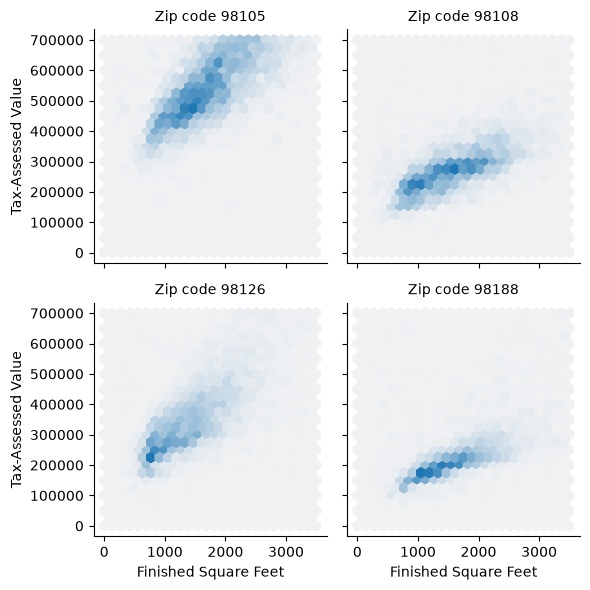

In [43]:
def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(
        x,
        y,
        gridsize=25,
        cmap=cmap,
        **kwargs
    )

g = sns.FacetGrid(
    kc_tax_zip,
    col='ZipCode',
    col_wrap=2
)

g.map(
    hexbin,
    'SqFtTotLiving',
    'TaxAssessedValue',
    extent=[0, 3500, 0, 700000]
)

g.set_axis_labels(
    'Finished Square Feet',
    'Tax-Assessed Value'
)

g.set_titles(
    'Zip code {col_name:.0f}'
)

## Summary

Exploratory Data Analysis (EDA) merupakan tahap penting untuk memahami data sebelum melakukan analisis atau pemodelan lebih lanjut.

Pada chapter ini telah dibahas:

- struktur dan tipe data,
- rectangular data,
- estimates of location,
- estimates of variability,
- distribusi data,
- data kategorikal,
- correlation,
- scatterplot,
- hexbin plot,
- contour plot,
- contingency table,
- boxplot,
- violin plot,
- dan conditioning.

Ukuran statistik memberikan ringkasan numerik, sedangkan visualisasi membantu mengidentifikasi pola, hubungan, distribusi, dan kemungkinan outlier.

EDA memberikan pemahaman awal mengenai karakteristik data dan menjadi dasar sebelum melakukan analisis statistik atau machine learning lebih lanjut.